# Smartphone Battery Health Prediction
## Machine Learning Model to Predict Battery Health and Recommended Actions

This notebook contains a complete pipeline for:
- Data loading and exploration
- Data preprocessing and feature engineering
- Exploratory Data Analysis (EDA)
- Model training and evaluation
- Prediction and insights

## 1. Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Data

In [2]:
# Load the datasets
features_df = pd.read_csv('smartphone_battery_features.csv')
targets_df = pd.read_csv('smartphone_battery_targets.csv')

print("Features dataset shape:", features_df.shape)
print("Targets dataset shape:", targets_df.shape)
print("\nData loaded successfully!")

Features dataset shape: (5000, 15)
Targets dataset shape: (5000, 3)

Data loaded successfully!


## 3. Data Exploration

In [3]:
# Display first few rows of features
print("=" * 80)
print("FEATURES DATASET - First 5 Rows")
print("=" * 80)
display(features_df.head())

print("\n" + "=" * 80)
print("FEATURES DATASET - Info")
print("=" * 80)
print(features_df.info())

print("\n" + "=" * 80)
print("FEATURES DATASET - Statistical Summary")
print("=" * 80)
display(features_df.describe())

FEATURES DATASET - First 5 Rows


,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95



FEATURES DATASET - Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Device_ID                         5000 non-null   object 
 1   device_age_months                 5000 non-null   int64  
 2   battery_capacity_mah              5000 non-null   int64  
 3   avg_screen_on_hours_per_day       5000 non-null   float64
 4   avg_charging_cycles_per_week      5000 non-null   float64
 5   avg_battery_temp_celsius          5000 non-null   float64
 6   fast_charging_usage_percent       5000 non-null   float64
 7   overnight_charging_freq_per_week  5000 non-null   int64  
 8   gaming_hours_per_week             5000 non-null   float64
 9   video_streaming_hours_per_week    5000 non-null   float64
 10  background_app_usage_level        5000 non-null   object 
 11  signal_strength_avg               5000 non-n

,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,charging_habit_score,usage_intensity_score,thermal_stress_index
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,24.232400,4134.700000,5.514120,8.33224,31.907360,50.712400,3.465200,4.012920,10.020740,6.582000,9.998394,3.079366
std,14.138004,745.061698,1.974704,3.03454,2.544528,22.227398,2.306307,2.834289,4.990648,1.225225,0.058542,0.674274
min,0.000000,3000.000000,1.000000,3.00000,21.600000,1.100000,0.000000,0.000000,0.000000,3.000000,6.570000,1.000000
25%,12.000000,4000.000000,4.200000,6.10000,30.200000,33.500000,1.000000,1.900000,6.600000,6.000000,10.000000,2.620000
50%,24.000000,4500.000000,5.500000,8.25000,31.900000,51.000000,3.000000,3.300000,10.000000,7.000000,10.000000,3.070000
75%,36.000000,5000.000000,6.900000,10.40000,33.600000,68.100000,5.000000,5.400000,13.400000,7.000000,10.000000,3.520000
max,48.000000,5000.000000,12.000000,18.60000,41.200000,99.100000,7.000000,24.800000,27.200000,10.000000,10.000000,6.180000


In [4]:
# Display first few rows of targets
print("=" * 80)
print("TARGETS DATASET - First 5 Rows")
print("=" * 80)
display(targets_df.head())

print("\n" + "=" * 80)
print("TARGETS DATASET - Info")
print("=" * 80)
print(targets_df.info())

print("\n" + "=" * 80)
print("TARGETS DATASET - Statistical Summary")
print("=" * 80)
display(targets_df.describe())

TARGETS DATASET - First 5 Rows


,Device_ID,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,67.2,Replace Battery



TARGETS DATASET - Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Device_ID                       5000 non-null   object 
 1   current_battery_health_percent  5000 non-null   float64
 2   recommended_action              5000 non-null   object 
dtypes: float64(1), object(2)
memory usage: 117.3+ KB
None

TARGETS DATASET - Statistical Summary


,current_battery_health_percent
count,5000.000000
mean,62.595600
std,17.723528
min,10.000000
25%,50.200000
50%,64.100000
75%,76.900000
max,100.000000


In [5]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES CHECK")
print("=" * 80)
print("\nFeatures dataset:")
print(features_df.isnull().sum())

print("\nTargets dataset:")
print(targets_df.isnull().sum())

MISSING VALUES CHECK

Features dataset:
Device_ID                           0
device_age_months                   0
battery_capacity_mah                0
avg_screen_on_hours_per_day         0
avg_charging_cycles_per_week        0
avg_battery_temp_celsius            0
fast_charging_usage_percent         0
overnight_charging_freq_per_week    0
gaming_hours_per_week               0
video_streaming_hours_per_week      0
background_app_usage_level          0
signal_strength_avg                 0
charging_habit_score                0
usage_intensity_score               0
thermal_stress_index                0
dtype: int64

Targets dataset:
Device_ID                         0
current_battery_health_percent    0
recommended_action                0
dtype: int64


In [6]:
# Check for duplicates
print("=" * 80)
print("DUPLICATE CHECK")
print("=" * 80)
print(f"\nDuplicate rows in features: {features_df.duplicated().sum()}")
print(f"Duplicate Device_IDs in features: {features_df['Device_ID'].duplicated().sum()}")
print(f"\nDuplicate rows in targets: {targets_df.duplicated().sum()}")
print(f"Duplicate Device_IDs in targets: {targets_df['Device_ID'].duplicated().sum()}")

DUPLICATE CHECK

Duplicate rows in features: 0
Duplicate Device_IDs in features: 0

Duplicate rows in targets: 0
Duplicate Device_IDs in targets: 0


In [7]:
# Check target variable distribution
print("=" * 80)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 80)
print("\nRecommended Action Distribution:")
print(targets_df['recommended_action'].value_counts())
print("\nPercentages:")
print(targets_df['recommended_action'].value_counts(normalize=True) * 100)

print("\nBattery Health Statistics:")
print(targets_df['current_battery_health_percent'].describe())

TARGET VARIABLE DISTRIBUTION

Recommended Action Distribution:
recommended_action
Replace Battery    2325
Keep Using         1440
Change Phone       1235
Name: count, dtype: int64

Percentages:
recommended_action
Replace Battery    46.5
Keep Using         28.8
Change Phone       24.7
Name: proportion, dtype: float64

Battery Health Statistics:
count    5000.000000
mean       62.595600
std        17.723528
min        10.000000
25%        50.200000
50%        64.100000
75%        76.900000
max       100.000000
Name: current_battery_health_percent, dtype: float64


## 4. Merge Datasets

In [8]:
# Merge features and targets on Device_ID
df = pd.merge(features_df, targets_df, on='Device_ID', how='inner')

print(f"Merged dataset shape: {df.shape}")
print(f"\nColumns in merged dataset: {df.columns.tolist()}")
display(df.head())

Merged dataset shape: (5000, 17)

Columns in merged dataset: ['Device_ID', 'device_age_months', 'battery_capacity_mah', 'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week', 'avg_battery_temp_celsius', 'fast_charging_usage_percent', 'overnight_charging_freq_per_week', 'gaming_hours_per_week', 'video_streaming_hours_per_week', 'background_app_usage_level', 'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score', 'thermal_stress_index', 'current_battery_health_percent', 'recommended_action']


,Device_ID,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,background_app_usage_level,signal_strength_avg,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent,recommended_action
0,207dd94c-0430-43aa-b388-4893447e628e,38,4500,7.1,11.4,34.8,90.8,7,7.9,14.0,Medium,Poor,4,10.0,4.04,32.8,Change Phone
1,3f4d1d33-ba89-4814-a168-7b4cc75be26b,28,3000,6.8,10.3,35.4,60.6,2,8.6,11.0,Medium,Good,7,10.0,4.23,50.3,Replace Battery
2,b4adca05-564f-4b70-ab69-e8d66e656463,14,3000,7.2,11.2,29.4,29.3,4,0.3,10.3,Medium,Good,6,10.0,2.21,66.1,Replace Battery
3,4147e039-31b7-480a-bbc9-03cd0f66e9f1,42,3000,5.5,8.3,32.8,62.5,0,1.9,4.9,Medium,Good,8,10.0,3.13,46.8,Change Phone
4,3f9b0fb7-73c2-4ab7-8e30-7b492097a3f5,7,3000,7.6,11.6,38.7,85.4,6,7.9,9.3,High,Good,5,10.0,4.95,67.2,Replace Battery


## 5. Exploratory Data Analysis (EDA)

In [9]:
# Analyze categorical variables
print("=" * 80)
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 80)

categorical_cols = ['background_app_usage_level', 'signal_strength_avg', 'recommended_action']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("-" * 40)

CATEGORICAL VARIABLES ANALYSIS

background_app_usage_level:
background_app_usage_level
Low       1707
Medium    1684
High      1609
Name: count, dtype: int64
----------------------------------------

signal_strength_avg:
signal_strength_avg
Good        3025
Moderate    1509
Poor         466
Name: count, dtype: int64
----------------------------------------

recommended_action:
recommended_action
Replace Battery    2325
Keep Using         1440
Change Phone       1235
Name: count, dtype: int64
----------------------------------------


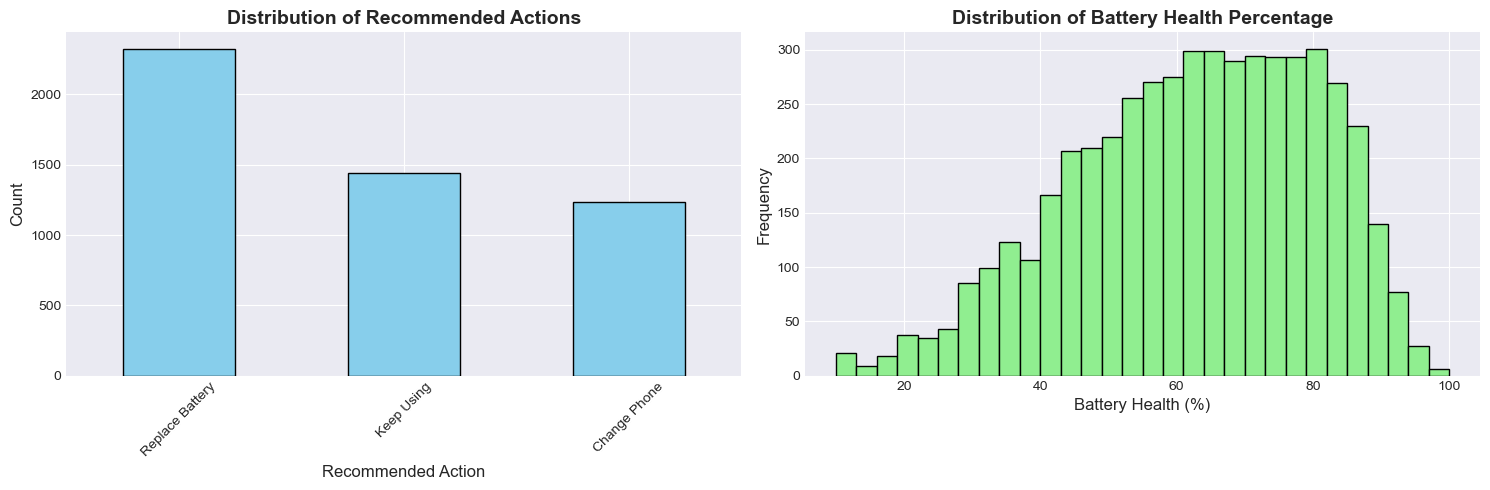

In [10]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Recommended Action distribution
df['recommended_action'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Recommended Actions', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Recommended Action', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Battery Health distribution
axes[1].hist(df['current_battery_health_percent'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Battery Health Percentage', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Battery Health (%)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

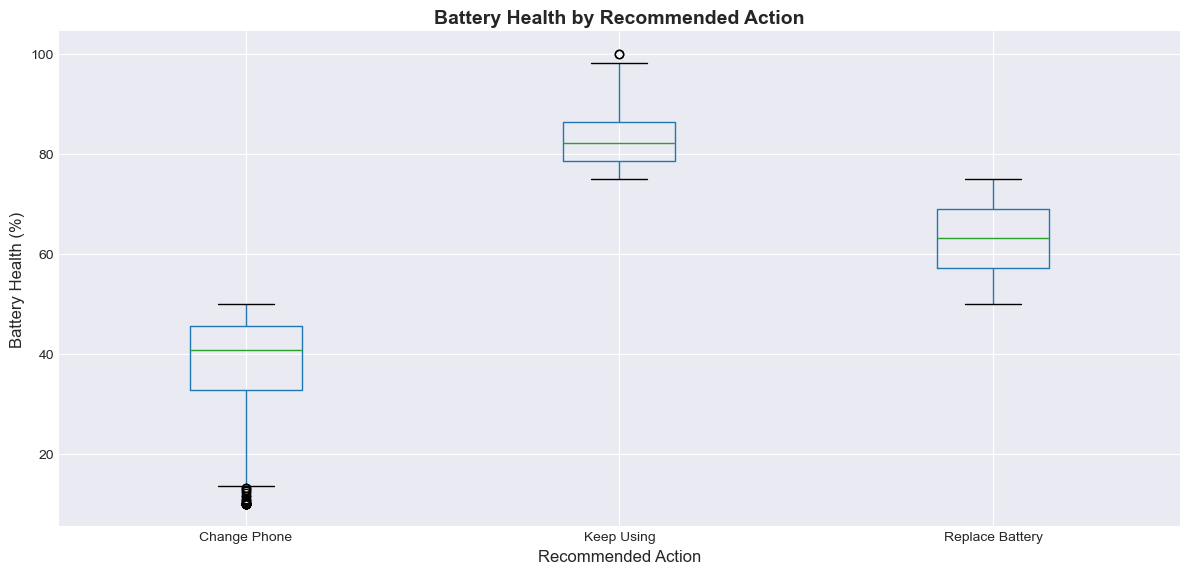

In [11]:
# Battery health by recommended action
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(column='current_battery_health_percent', by='recommended_action', ax=ax)
ax.set_title('Battery Health by Recommended Action', fontsize=14, fontweight='bold')
ax.set_xlabel('Recommended Action', fontsize=12)
ax.set_ylabel('Battery Health (%)', fontsize=12)
plt.suptitle('')  # Remove the automatic title
plt.tight_layout()
plt.show()

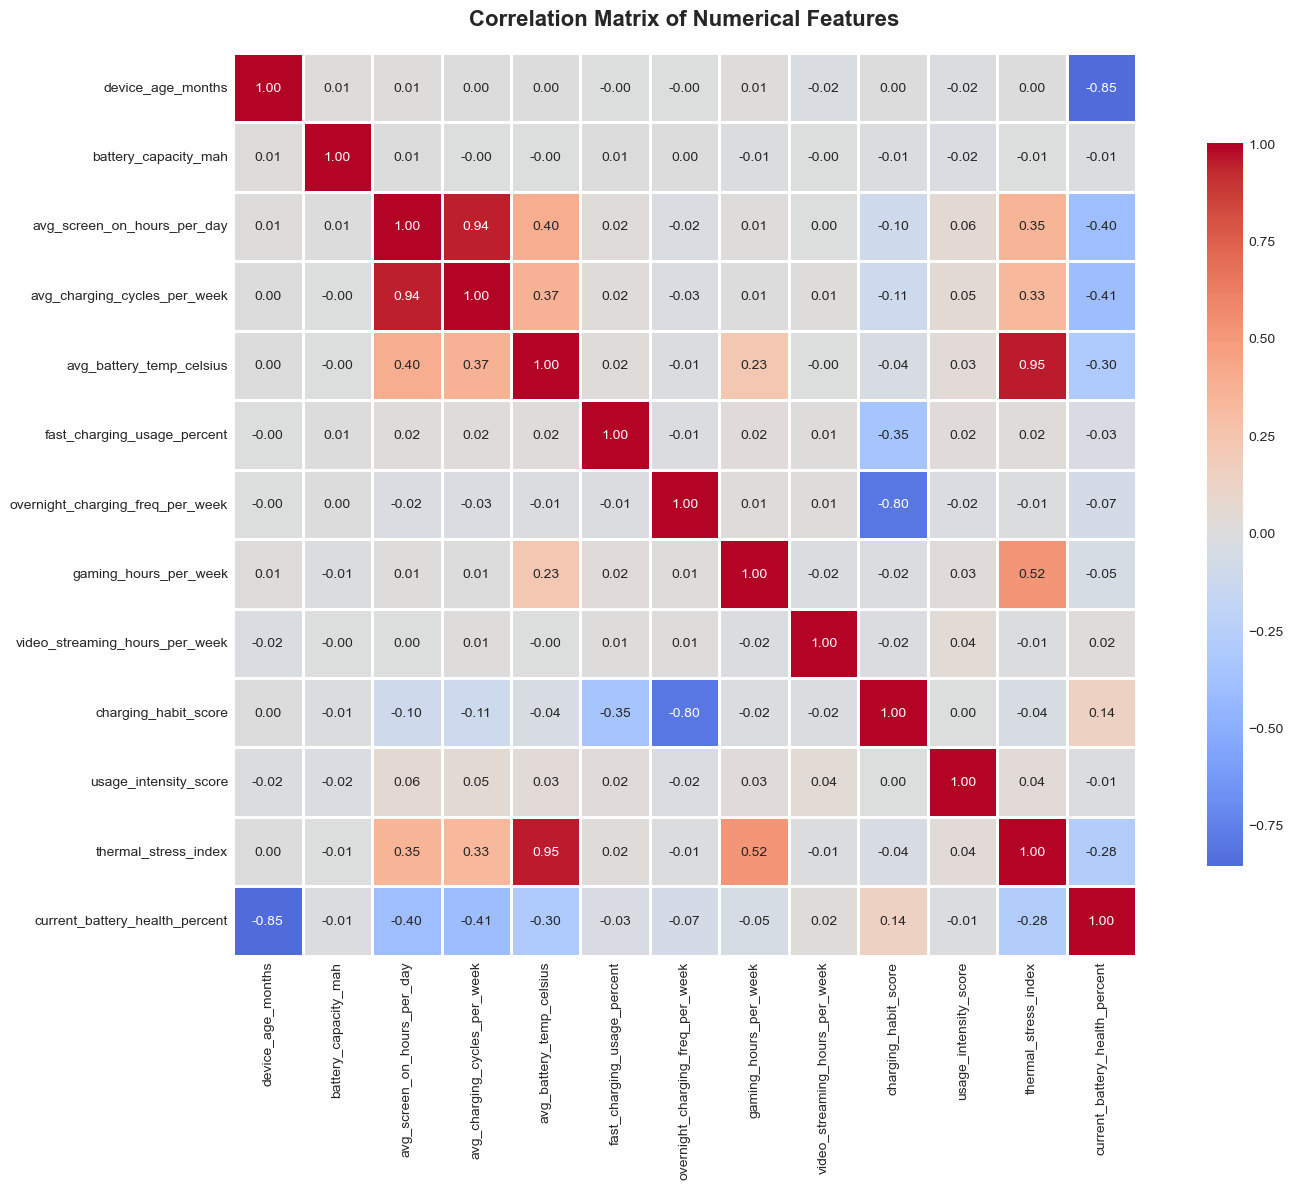

In [12]:
# Correlation analysis for numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Device_ID') if 'Device_ID' in numerical_cols else None

# Correlation matrix
plt.figure(figsize=(16, 12))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

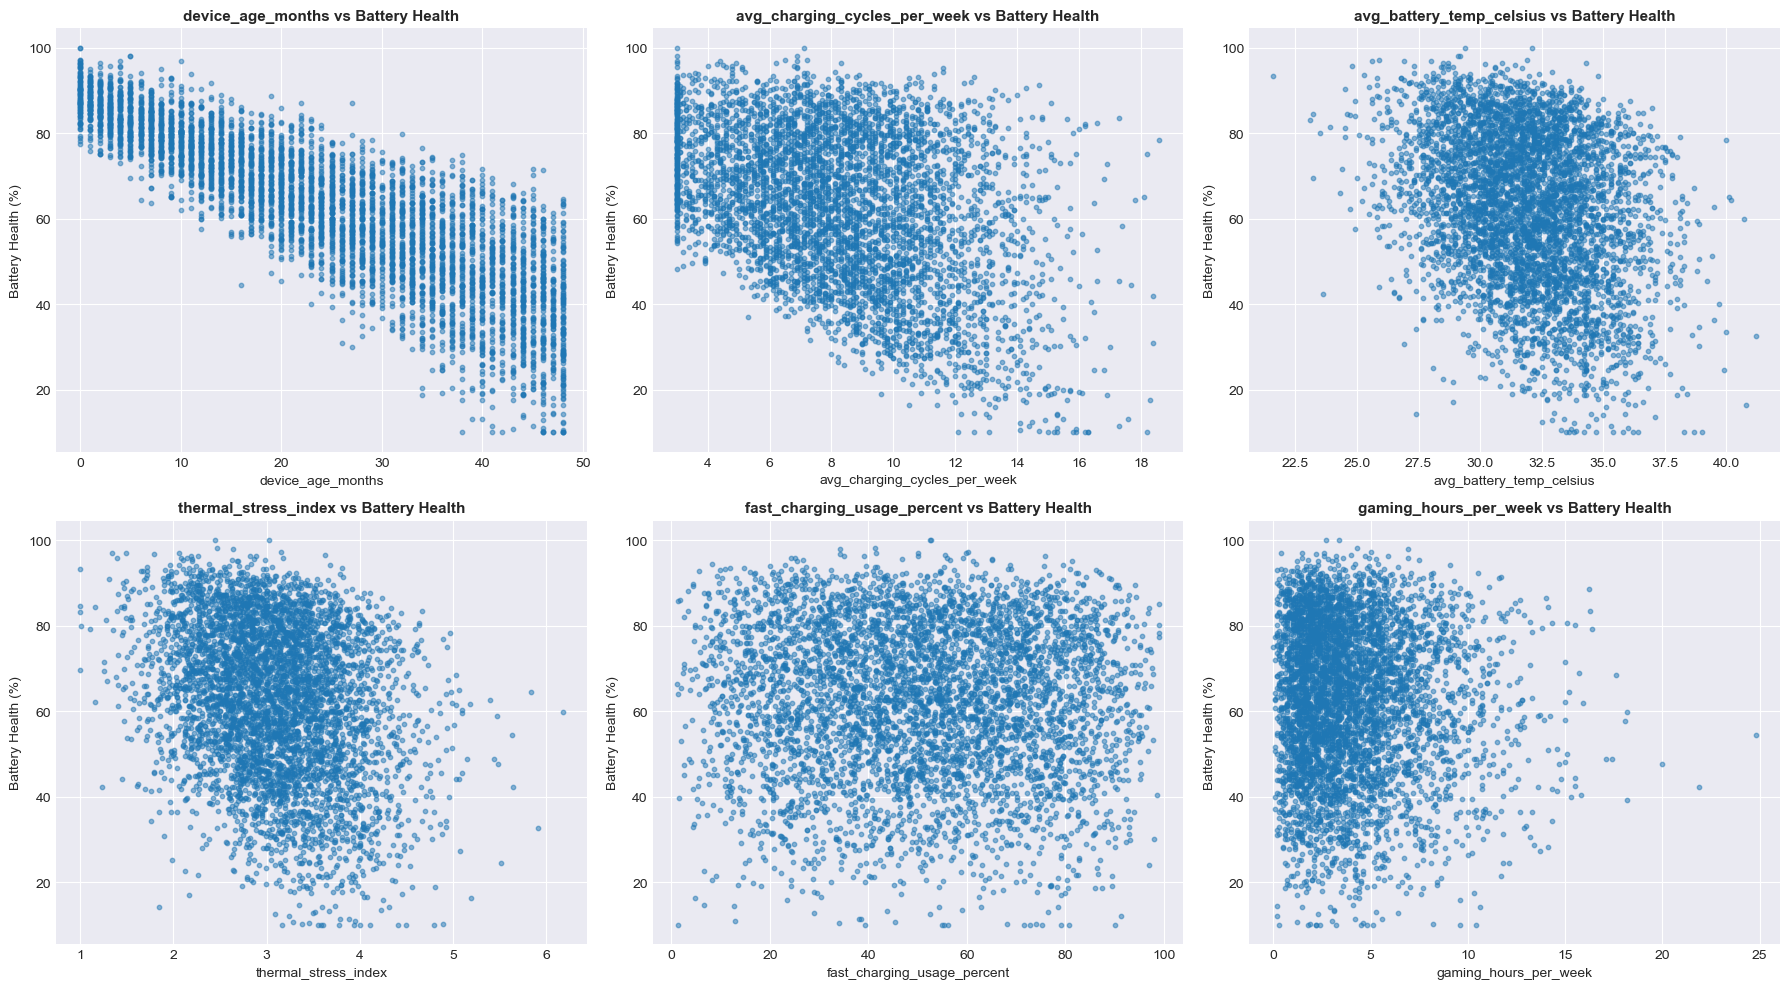

In [13]:
# Key features vs Battery Health
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

key_features = ['device_age_months', 'avg_charging_cycles_per_week', 
                'avg_battery_temp_celsius', 'thermal_stress_index',
                'fast_charging_usage_percent', 'gaming_hours_per_week']

for idx, feature in enumerate(key_features):
    axes[idx].scatter(df[feature], df['current_battery_health_percent'], alpha=0.5, s=10)
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Battery Health (%)', fontsize=10)
    axes[idx].set_title(f'{feature} vs Battery Health', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

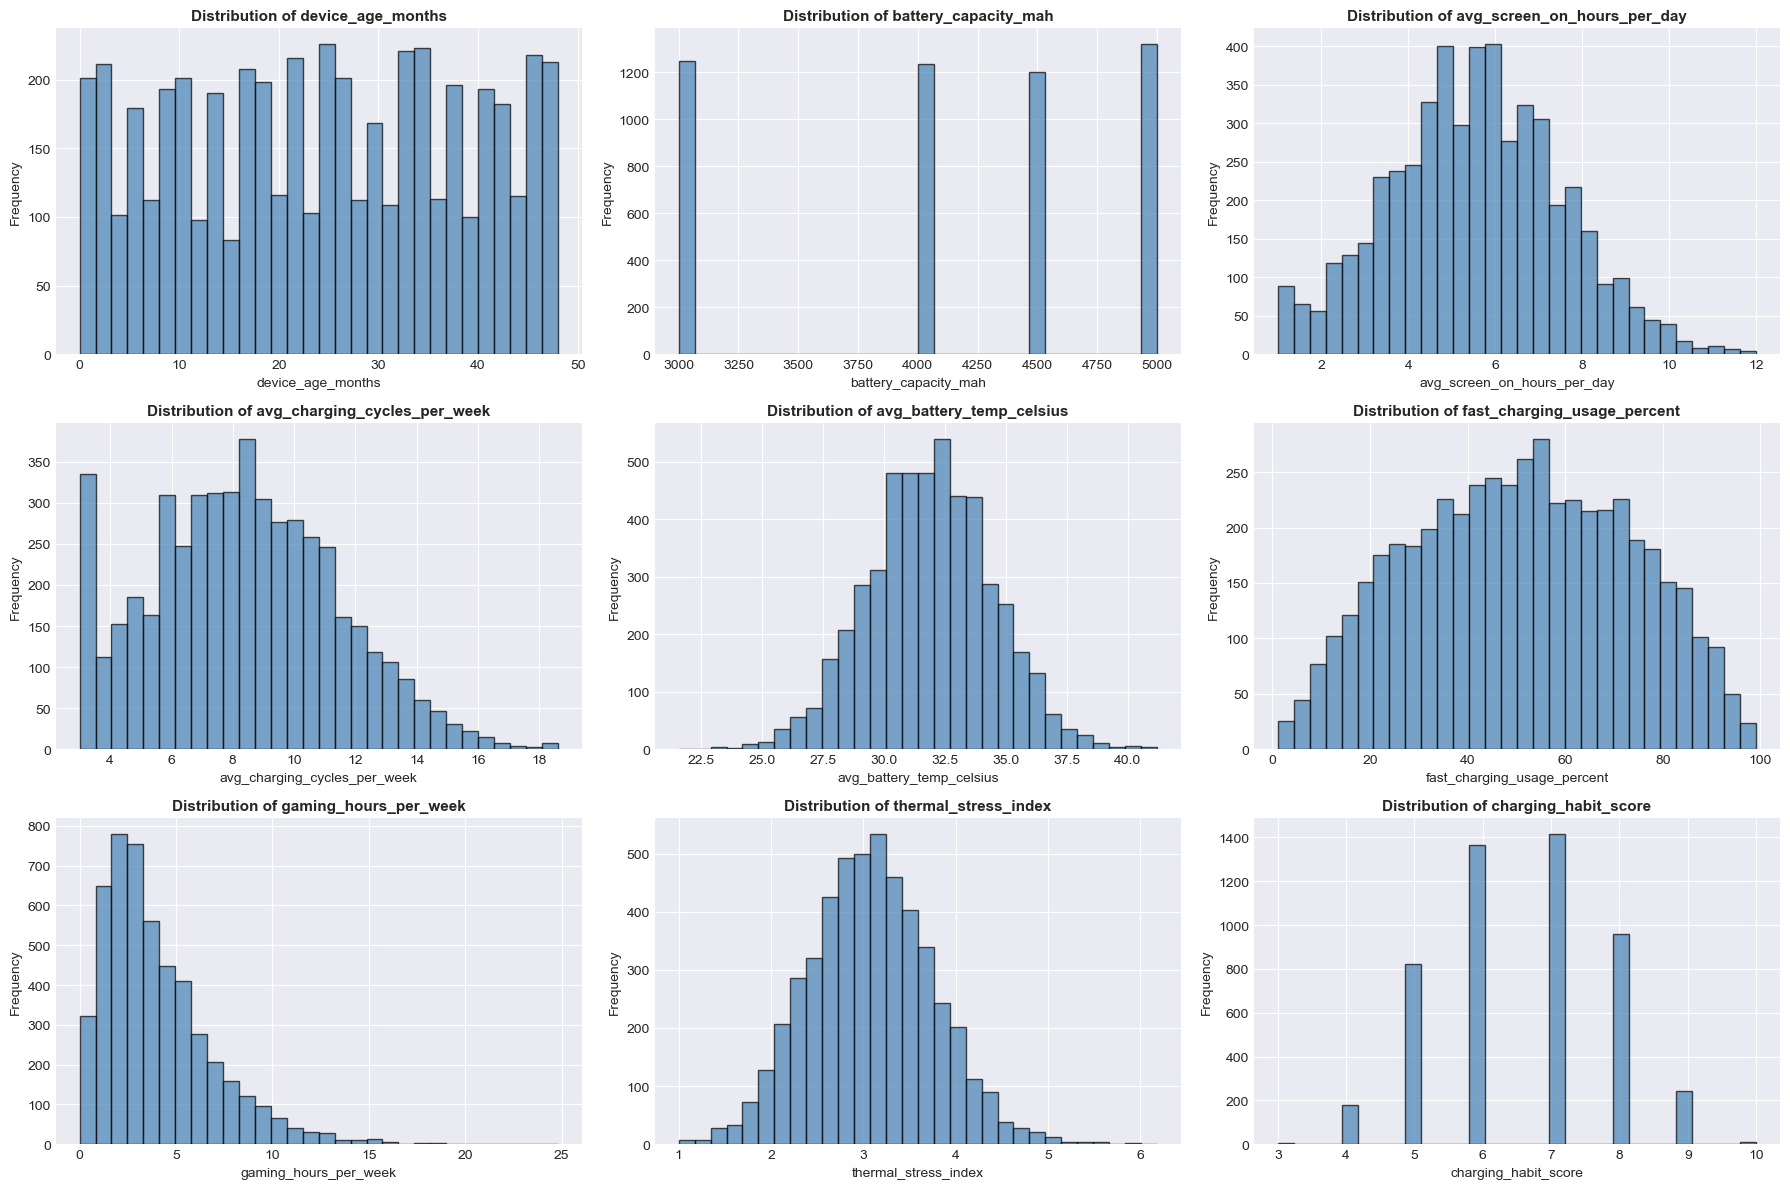

In [14]:
# Distribution of key numerical features
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

plot_features = ['device_age_months', 'battery_capacity_mah', 'avg_screen_on_hours_per_day',
                 'avg_charging_cycles_per_week', 'avg_battery_temp_celsius', 
                 'fast_charging_usage_percent', 'gaming_hours_per_week',
                 'thermal_stress_index', 'charging_habit_score']

for idx, feature in enumerate(plot_features):
    axes[idx].hist(df[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Data Preprocessing

In [15]:
# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical variables
label_encoders = {}

categorical_features = ['background_app_usage_level', 'signal_strength_avg']

for col in categorical_features:
    le = LabelEncoder()
    df_processed[col + '_encoded'] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"\n{col} encoding:")
    for i, label in enumerate(le.classes_):
        print(f"  {label} -> {i}")

# Encode target variable (recommended_action)
le_target = LabelEncoder()
df_processed['recommended_action_encoded'] = le_target.fit_transform(df_processed['recommended_action'])
label_encoders['recommended_action'] = le_target

print("\nrecommended_action encoding:")
for i, label in enumerate(le_target.classes_):
    print(f"  {label} -> {i}")

print("\nCategorical encoding completed!")


background_app_usage_level encoding:
  High -> 0
  Low -> 1
  Medium -> 2

signal_strength_avg encoding:
  Good -> 0
  Moderate -> 1
  Poor -> 2

recommended_action encoding:
  Change Phone -> 0
  Keep Using -> 1
  Replace Battery -> 2

Categorical encoding completed!


In [16]:
# Feature Engineering - Create additional features
print("Creating engineered features...\n")

# Battery stress indicator
df_processed['battery_stress_score'] = (
    df_processed['thermal_stress_index'] * 
    df_processed['avg_charging_cycles_per_week'] * 
    df_processed['fast_charging_usage_percent'] / 100
)

# Usage intensity
df_processed['total_usage_hours'] = (
    df_processed['avg_screen_on_hours_per_day'] * 7 +
    df_processed['gaming_hours_per_week'] +
    df_processed['video_streaming_hours_per_week']
)

# Age to capacity ratio
df_processed['age_capacity_ratio'] = (
    df_processed['device_age_months'] / df_processed['battery_capacity_mah'] * 1000
)

# Charging intensity
df_processed['charging_intensity'] = (
    df_processed['avg_charging_cycles_per_week'] * 
    df_processed['overnight_charging_freq_per_week']
)

# Temperature stress
df_processed['temp_stress'] = (
    df_processed['avg_battery_temp_celsius'] * df_processed['thermal_stress_index']
)

print("Engineered features created:")
print("  - battery_stress_score")
print("  - total_usage_hours")
print("  - age_capacity_ratio")
print("  - charging_intensity")
print("  - temp_stress")
print("\nFeature engineering completed!")

Creating engineered features...

Engineered features created:
  - battery_stress_score
  - total_usage_hours
  - age_capacity_ratio
  - charging_intensity
  - temp_stress

Feature engineering completed!


## 7. Prepare Data for Modeling

In [17]:
# Select features for modeling
feature_columns = [
    'device_age_months', 'battery_capacity_mah', 'avg_screen_on_hours_per_day',
    'avg_charging_cycles_per_week', 'avg_battery_temp_celsius', 
    'fast_charging_usage_percent', 'overnight_charging_freq_per_week',
    'gaming_hours_per_week', 'video_streaming_hours_per_week',
    'background_app_usage_level_encoded', 'signal_strength_avg_encoded',
    'charging_habit_score', 'usage_intensity_score', 'thermal_stress_index',
    'battery_stress_score', 'total_usage_hours', 'age_capacity_ratio',
    'charging_intensity', 'temp_stress'
]

# Features (X)
X = df_processed[feature_columns]

# Targets (y)
y_regression = df_processed['current_battery_health_percent']  # For regression
y_classification = df_processed['recommended_action_encoded']  # For classification

print(f"Feature matrix shape: {X.shape}")
print(f"Regression target shape: {y_regression.shape}")
print(f"Classification target shape: {y_classification.shape}")
print(f"\nNumber of features: {len(feature_columns)}")
print(f"\nFeatures used:\n{feature_columns}")

Feature matrix shape: (5000, 19)
Regression target shape: (5000,)
Classification target shape: (5000,)

Number of features: 19

Features used:
['device_age_months', 'battery_capacity_mah', 'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week', 'avg_battery_temp_celsius', 'fast_charging_usage_percent', 'overnight_charging_freq_per_week', 'gaming_hours_per_week', 'video_streaming_hours_per_week', 'background_app_usage_level_encoded', 'signal_strength_avg_encoded', 'charging_habit_score', 'usage_intensity_score', 'thermal_stress_index', 'battery_stress_score', 'total_usage_hours', 'age_capacity_ratio', 'charging_intensity', 'temp_stress']


In [18]:
# Split data into training and testing sets
# For regression (battery health prediction)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regression, test_size=0.2, random_state=42
)

# For classification (recommended action prediction)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification
)

print("Data split completed!")
print("\nRegression:")
print(f"  Training set: {X_train_reg.shape}")
print(f"  Testing set: {X_test_reg.shape}")
print("\nClassification:")
print(f"  Training set: {X_train_clf.shape}")
print(f"  Testing set: {X_test_clf.shape}")

Data split completed!

Regression:
  Training set: (4000, 19)
  Testing set: (1000, 19)

Classification:
  Training set: (4000, 19)
  Testing set: (1000, 19)


In [19]:
# Feature Scaling
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)

print("Feature scaling completed!")
print(f"\nScaled training features shape: {X_train_reg_scaled.shape}")
print(f"Scaled testing features shape: {X_test_reg_scaled.shape}")

Feature scaling completed!

Scaled training features shape: (4000, 19)
Scaled testing features shape: (1000, 19)


## 8. Regression Models - Battery Health Prediction

In [20]:
# Train multiple regression models
print("=" * 80)
print("REGRESSION MODELS - BATTERY HEALTH PREDICTION")
print("=" * 80)

regression_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

regression_results = {}

for name, model in regression_models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_reg_scaled, y_train_reg)
    
    # Make predictions
    y_pred_train = model.predict(X_train_reg_scaled)
    y_pred_test = model.predict(X_test_reg_scaled)
    
    # Calculate metrics
    train_r2 = r2_score(y_train_reg, y_pred_train)
    test_r2 = r2_score(y_test_reg, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))
    train_mae = mean_absolute_error(y_train_reg, y_pred_train)
    test_mae = mean_absolute_error(y_test_reg, y_pred_test)
    
    # Store results
    regression_results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'predictions': y_pred_test
    }
    
    # Print results
    print(f"\n{name} Results:")
    print(f"  Training R² Score: {train_r2:.4f}")
    print(f"  Testing R² Score: {test_r2:.4f}")
    print(f"  Training RMSE: {train_rmse:.4f}")
    print(f"  Testing RMSE: {test_rmse:.4f}")
    print(f"  Training MAE: {train_mae:.4f}")
    print(f"  Testing MAE: {test_mae:.4f}")
    print("-" * 80)

print("\nRegression models training completed!")

REGRESSION MODELS - BATTERY HEALTH PREDICTION

Training Linear Regression...

Linear Regression Results:
  Training R² Score: 0.9314
  Testing R² Score: 0.9299
  Training RMSE: 4.6434
  Testing RMSE: 4.6848
  Training MAE: 3.5777
  Testing MAE: 3.6750
--------------------------------------------------------------------------------

Training Random Forest Regressor...

Random Forest Regressor Results:
  Training R² Score: 0.9942
  Testing R² Score: 0.9575
  Training RMSE: 1.3492
  Testing RMSE: 3.6478
  Training MAE: 1.0634
  Testing MAE: 2.9203
--------------------------------------------------------------------------------

Regression models training completed!


In [21]:
# Compare regression models
comparison_df = pd.DataFrame({
    'Model': list(regression_results.keys()),
    'Train R²': [regression_results[m]['train_r2'] for m in regression_results.keys()],
    'Test R²': [regression_results[m]['test_r2'] for m in regression_results.keys()],
    'Train RMSE': [regression_results[m]['train_rmse'] for m in regression_results.keys()],
    'Test RMSE': [regression_results[m]['test_rmse'] for m in regression_results.keys()],
    'Train MAE': [regression_results[m]['train_mae'] for m in regression_results.keys()],
    'Test MAE': [regression_results[m]['test_mae'] for m in regression_results.keys()]
})

print("\n" + "=" * 80)
print("REGRESSION MODELS COMPARISON")
print("=" * 80)
display(comparison_df)

# Find best model
best_reg_model_name = comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Model']
print(f"\nBest Regression Model: {best_reg_model_name}")
print(f"Test R² Score: {comparison_df.loc[comparison_df['Test R²'].idxmax(), 'Test R²']:.4f}")


REGRESSION MODELS COMPARISON


,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
0,Linear Regression,0.931398,0.929904,4.643399,4.684814,3.577667,3.675002
1,Random Forest Regressor,0.994208,0.957502,1.349214,3.647799,1.063413,2.920289



Best Regression Model: Random Forest Regressor
Test R² Score: 0.9575


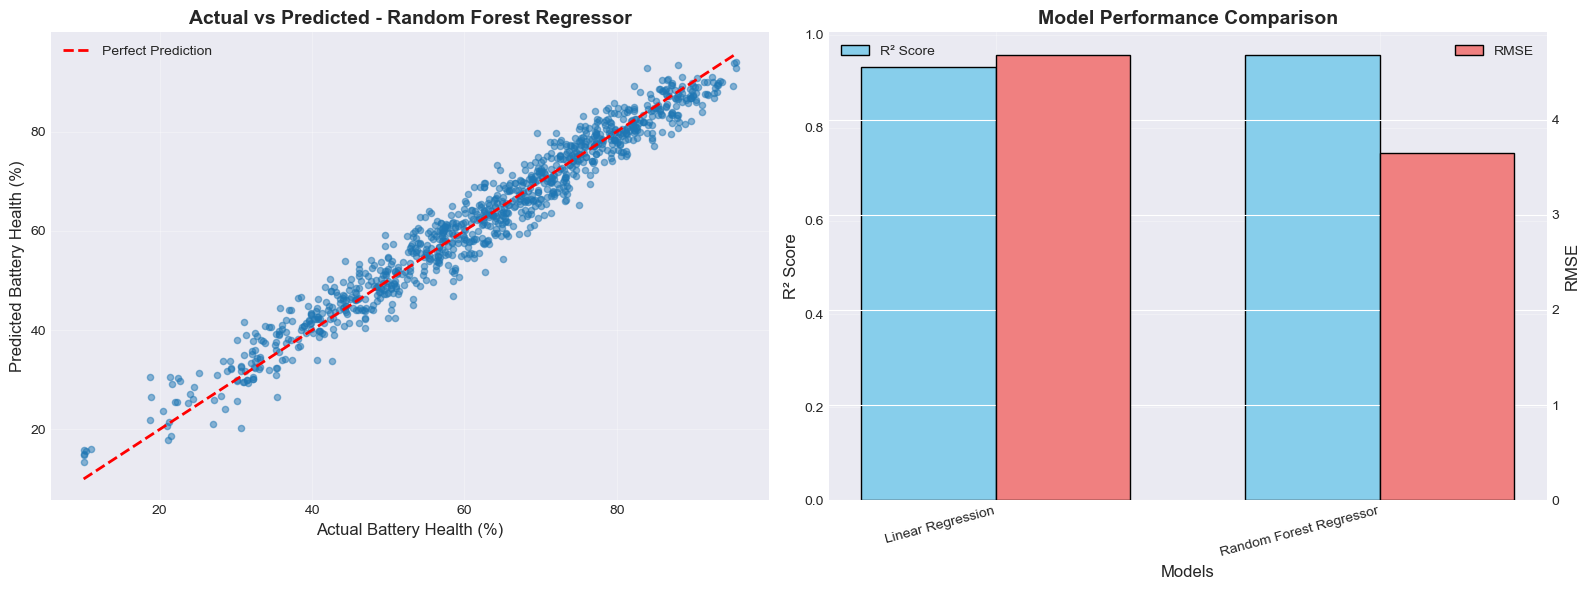

In [22]:
# Visualize regression results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted for best model
best_predictions = regression_results[best_reg_model_name]['predictions']
axes[0].scatter(y_test_reg, best_predictions, alpha=0.5, s=20)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], 
             [y_test_reg.min(), y_test_reg.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Battery Health (%)', fontsize=12)
axes[0].set_ylabel('Predicted Battery Health (%)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted - {best_reg_model_name}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Model comparison
models = comparison_df['Model'].tolist()
test_r2_scores = comparison_df['Test R²'].tolist()
test_rmse_scores = comparison_df['Test RMSE'].tolist()

x_pos = np.arange(len(models))
width = 0.35

axes[1].bar(x_pos - width/2, test_r2_scores, width, label='R² Score', color='skyblue', edgecolor='black')
ax2 = axes[1].twinx()
ax2.bar(x_pos + width/2, test_rmse_scores, width, label='RMSE', color='lightcoral', edgecolor='black')

axes[1].set_xlabel('Models', fontsize=12)
axes[1].set_ylabel('R² Score', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


FEATURE IMPORTANCE - RANDOM FOREST REGRESSOR


,Feature,Importance
0,device_age_months,0.731120
3,avg_charging_cycles_per_week,0.172362
4,avg_battery_temp_celsius,0.023881
2,avg_screen_on_hours_per_day,0.017231
18,temp_stress,0.010664
17,charging_intensity,0.008395
16,age_capacity_ratio,0.007172
14,battery_stress_score,0.005854
13,thermal_stress_index,0.004782
15,total_usage_hours,0.003493


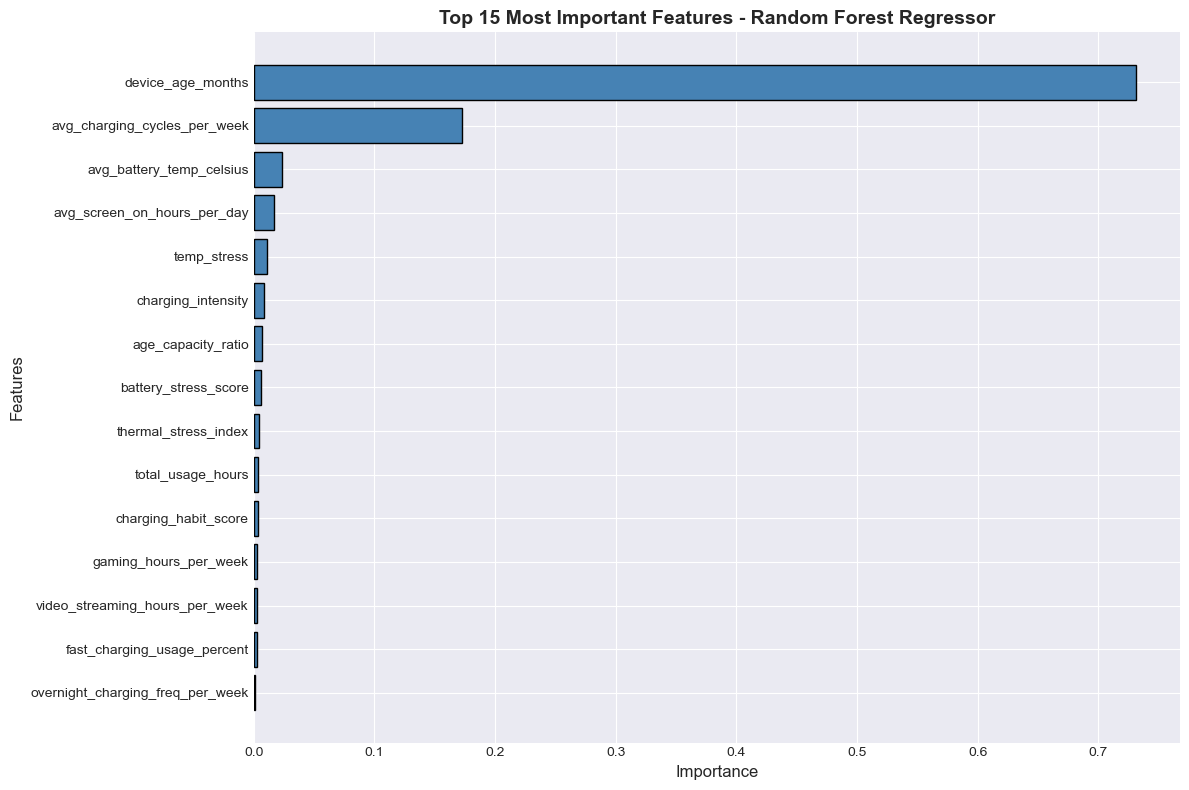

In [23]:
# Feature importance for Random Forest Regressor
if 'Random Forest Regressor' in regression_results:
    rf_model = regression_results['Random Forest Regressor']['model']
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "=" * 80)
    print("FEATURE IMPORTANCE - RANDOM FOREST REGRESSOR")
    print("=" * 80)
    display(feature_importance)
    
    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['Feature'].head(15), 
             feature_importance['Importance'].head(15),
             color='steelblue', edgecolor='black')
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title('Top 15 Most Important Features - Random Forest Regressor', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 9. Classification Models - Recommended Action Prediction

In [40]:
#Additional
from sklearn.svm import SVC

In [51]:
# Train multiple classification models
print("=" * 80)
print("CLASSIFICATION MODELS - RECOMMENDED ACTION PREDICTION")
print("=" * 80)

classification_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42, kernel="linear", C=21)
    
}

classification_results = {}

for name, model in classification_models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_clf_scaled, y_train_clf)
    
    # Make predictions
    y_pred_train = model.predict(X_train_clf_scaled)
    y_pred_test = model.predict(X_test_clf_scaled)
    
    # Calculate accuracy
    train_accuracy = accuracy_score(y_train_clf, y_pred_train)
    test_accuracy = accuracy_score(y_test_clf, y_pred_test)
    
    # Store results
    classification_results[name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'predictions': y_pred_test
    }
    
    # Print results
    print(f"\n{name} Results:")
    print(f"  Training Accuracy: {train_accuracy:.4f}")
    print(f"  Testing Accuracy: {test_accuracy:.4f}")
    print("-" * 80)

print("\nClassification models training completed!")

CLASSIFICATION MODELS - RECOMMENDED ACTION PREDICTION

Training Logistic Regression...

Logistic Regression Results:
  Training Accuracy: 0.9105
  Testing Accuracy: 0.9030
--------------------------------------------------------------------------------

Training Decision Tree...

Decision Tree Results:
  Training Accuracy: 1.0000
  Testing Accuracy: 0.8440
--------------------------------------------------------------------------------

Training Random Forest...

Random Forest Results:
  Training Accuracy: 1.0000
  Testing Accuracy: 0.8870
--------------------------------------------------------------------------------

Training Gradient Boosting...

Gradient Boosting Results:
  Training Accuracy: 0.9520
  Testing Accuracy: 0.8940
--------------------------------------------------------------------------------

Training SVM...

SVM Results:
  Training Accuracy: 0.9105
  Testing Accuracy: 0.8970
--------------------------------------------------------------------------------

Classifica

In [52]:
# Compare classification models
clf_comparison_df = pd.DataFrame({
    'Model': list(classification_results.keys()),
    'Train Accuracy': [classification_results[m]['train_accuracy'] for m in classification_results.keys()],
    'Test Accuracy': [classification_results[m]['test_accuracy'] for m in classification_results.keys()]
})

print("\n" + "=" * 80)
print("CLASSIFICATION MODELS COMPARISON")
print("=" * 80)
display(clf_comparison_df)

# Find best model
best_clf_model_name = clf_comparison_df.loc[clf_comparison_df['Test Accuracy'].idxmax(), 'Model']
print(f"\nBest Classification Model: {best_clf_model_name}")
print(f"Test Accuracy: {clf_comparison_df.loc[clf_comparison_df['Test Accuracy'].idxmax(), 'Test Accuracy']:.4f}")


CLASSIFICATION MODELS COMPARISON


,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.9105,0.903
1,Decision Tree,1.0000,0.844
2,Random Forest,1.0000,0.887
3,Gradient Boosting,0.9520,0.894
4,SVM,0.9105,0.897



Best Classification Model: Logistic Regression
Test Accuracy: 0.9030


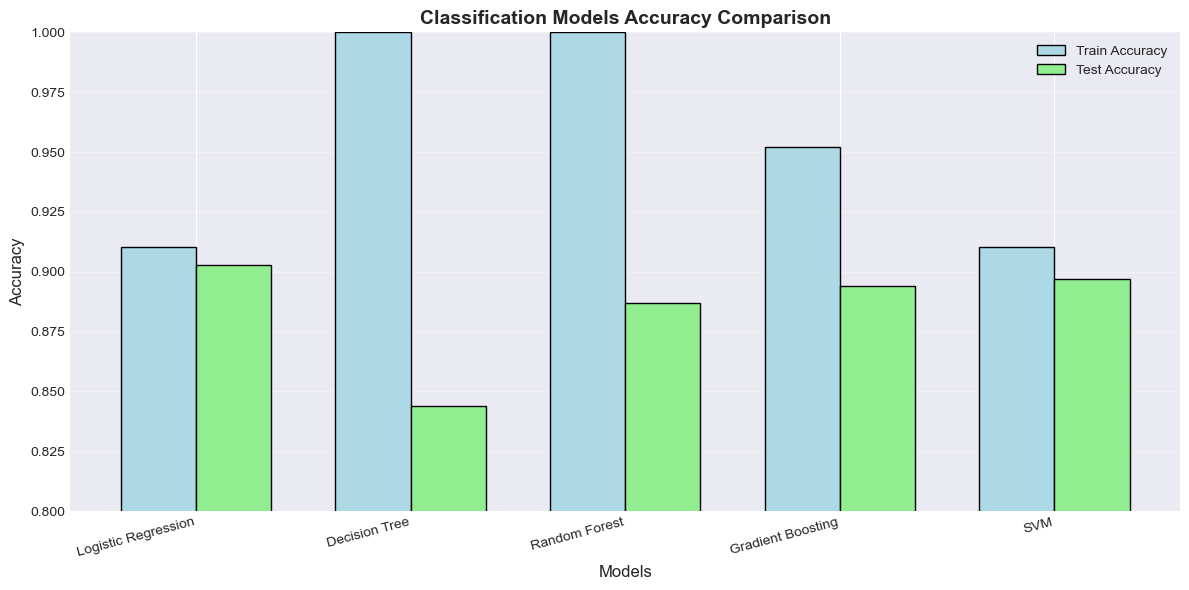

In [53]:
# Visualize classification results
plt.figure(figsize=(12, 6))

models = clf_comparison_df['Model'].tolist()
train_acc = clf_comparison_df['Train Accuracy'].tolist()
test_acc = clf_comparison_df['Test Accuracy'].tolist()

x_pos = np.arange(len(models))
width = 0.35

plt.bar(x_pos - width/2, train_acc, width, label='Train Accuracy', 
        color='lightblue', edgecolor='black')
plt.bar(x_pos + width/2, test_acc, width, label='Test Accuracy', 
        color='lightgreen', edgecolor='black')

plt.xlabel('Models', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Classification Models Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xticks(x_pos, models, rotation=15, ha='right')
plt.legend()
plt.ylim([0.8, 1.0])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [27]:
# Detailed classification report for best model
best_clf_predictions = classification_results[best_clf_model_name]['predictions']

print("=" * 80)
print(f"CLASSIFICATION REPORT - {best_clf_model_name}")
print("=" * 80)
print(classification_report(y_test_clf, best_clf_predictions, 
                          target_names=le_target.classes_))

CLASSIFICATION REPORT - Logistic Regression
                 precision    recall  f1-score   support

   Change Phone       0.90      0.88      0.89       247
     Keep Using       0.94      0.90      0.92       288
Replace Battery       0.88      0.91      0.90       465

       accuracy                           0.90      1000
      macro avg       0.91      0.90      0.90      1000
   weighted avg       0.90      0.90      0.90      1000



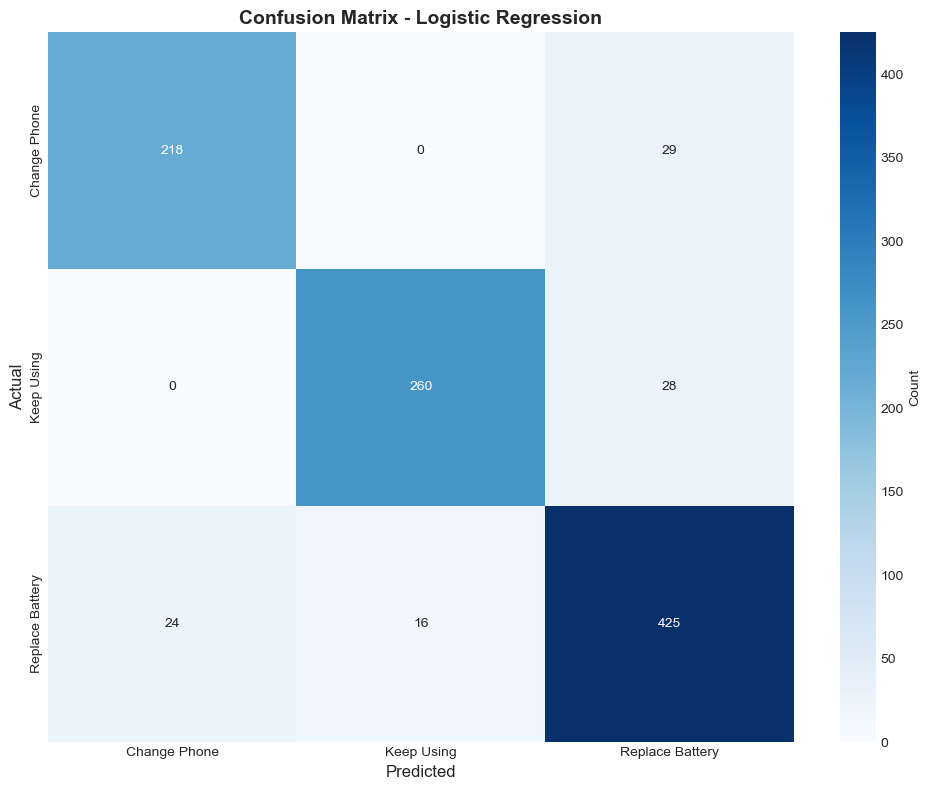

In [28]:
# Confusion Matrix
cm = confusion_matrix(y_test_clf, best_clf_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title(f'Confusion Matrix - {best_clf_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Feature importance for best classification model
if hasattr(classification_results[best_clf_model_name]['model'], 'feature_importances_'):
    clf_model = classification_results[best_clf_model_name]['model']
    feature_importance_clf = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': clf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\n" + "=" * 80)
    print(f"FEATURE IMPORTANCE - {best_clf_model_name}")
    print("=" * 80)
    display(feature_importance_clf)
    
    # Visualize feature importance
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance_clf['Feature'].head(15), 
             feature_importance_clf['Importance'].head(15),
             color='coral', edgecolor='black')
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title(f'Top 15 Most Important Features - {best_clf_model_name}', 
              fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 10. Make Predictions on New Data

In [30]:
# Create sample prediction function
def predict_battery_status(device_data):
    """
    Predict battery health and recommended action for a device.
    
    Parameters:
    device_data: dict with device features
    
    Returns:
    Dictionary with predictions
    """
    # Convert to DataFrame
    df_sample = pd.DataFrame([device_data])
    
    # Encode categorical features
    df_sample['background_app_usage_level_encoded'] = label_encoders['background_app_usage_level'].transform(
        df_sample['background_app_usage_level']
    )
    df_sample['signal_strength_avg_encoded'] = label_encoders['signal_strength_avg'].transform(
        df_sample['signal_strength_avg']
    )
    
    # Feature engineering
    df_sample['battery_stress_score'] = (
        df_sample['thermal_stress_index'] * 
        df_sample['avg_charging_cycles_per_week'] * 
        df_sample['fast_charging_usage_percent'] / 100
    )
    df_sample['total_usage_hours'] = (
        df_sample['avg_screen_on_hours_per_day'] * 7 +
        df_sample['gaming_hours_per_week'] +
        df_sample['video_streaming_hours_per_week']
    )
    df_sample['age_capacity_ratio'] = (
        df_sample['device_age_months'] / df_sample['battery_capacity_mah'] * 1000
    )
    df_sample['charging_intensity'] = (
        df_sample['avg_charging_cycles_per_week'] * 
        df_sample['overnight_charging_freq_per_week']
    )
    df_sample['temp_stress'] = (
        df_sample['avg_battery_temp_celsius'] * df_sample['thermal_stress_index']
    )
    
    # Select features
    X_sample = df_sample[feature_columns]
    
    # Scale features
    X_sample_scaled = scaler.transform(X_sample)
    
    # Make predictions
    battery_health_pred = regression_results[best_reg_model_name]['model'].predict(X_sample_scaled)[0]
    action_pred_encoded = classification_results[best_clf_model_name]['model'].predict(X_sample_scaled)[0]
    action_pred = label_encoders['recommended_action'].inverse_transform([action_pred_encoded])[0]
    
    return {
        'predicted_battery_health': round(battery_health_pred, 2),
        'recommended_action': action_pred
    }

print("Prediction function created successfully!")

Prediction function created successfully!


In [31]:
# Example predictions
print("=" * 80)
print("EXAMPLE PREDICTIONS")
print("=" * 80)

# Example 1: Old device with heavy usage
device_1 = {
    'device_age_months': 36,
    'battery_capacity_mah': 3000,
    'avg_screen_on_hours_per_day': 8.0,
    'avg_charging_cycles_per_week': 12.0,
    'avg_battery_temp_celsius': 38.0,
    'fast_charging_usage_percent': 85.0,
    'overnight_charging_freq_per_week': 7,
    'gaming_hours_per_week': 15.0,
    'video_streaming_hours_per_week': 20.0,
    'background_app_usage_level': 'High',
    'signal_strength_avg': 'Poor',
    'charging_habit_score': 3,
    'usage_intensity_score': 10.0,
    'thermal_stress_index': 5.0
}

result_1 = predict_battery_status(device_1)
print("\nDevice 1 (Old device with heavy usage):")
print(f"  Predicted Battery Health: {result_1['predicted_battery_health']}%")
print(f"  Recommended Action: {result_1['recommended_action']}")

# Example 2: New device with moderate usage
device_2 = {
    'device_age_months': 6,
    'battery_capacity_mah': 4500,
    'avg_screen_on_hours_per_day': 5.0,
    'avg_charging_cycles_per_week': 7.0,
    'avg_battery_temp_celsius': 30.0,
    'fast_charging_usage_percent': 40.0,
    'overnight_charging_freq_per_week': 3,
    'gaming_hours_per_week': 5.0,
    'video_streaming_hours_per_week': 10.0,
    'background_app_usage_level': 'Medium',
    'signal_strength_avg': 'Good',
    'charging_habit_score': 8,
    'usage_intensity_score': 10.0,
    'thermal_stress_index': 2.5
}

result_2 = predict_battery_status(device_2)
print("\nDevice 2 (New device with moderate usage):")
print(f"  Predicted Battery Health: {result_2['predicted_battery_health']}%")
print(f"  Recommended Action: {result_2['recommended_action']}")

# Example 3: Mid-age device with good habits
device_3 = {
    'device_age_months': 18,
    'battery_capacity_mah': 4000,
    'avg_screen_on_hours_per_day': 6.0,
    'avg_charging_cycles_per_week': 8.0,
    'avg_battery_temp_celsius': 32.0,
    'fast_charging_usage_percent': 50.0,
    'overnight_charging_freq_per_week': 4,
    'gaming_hours_per_week': 8.0,
    'video_streaming_hours_per_week': 12.0,
    'background_app_usage_level': 'Low',
    'signal_strength_avg': 'Good',
    'charging_habit_score': 7,
    'usage_intensity_score': 10.0,
    'thermal_stress_index': 3.0
}

result_3 = predict_battery_status(device_3)
print("\nDevice 3 (Mid-age device with good habits):")
print(f"  Predicted Battery Health: {result_3['predicted_battery_health']}%")
print(f"  Recommended Action: {result_3['recommended_action']}")

EXAMPLE PREDICTIONS

Device 1 (Old device with heavy usage):
  Predicted Battery Health: 29.78%
  Recommended Action: Change Phone

Device 2 (New device with moderate usage):
  Predicted Battery Health: 86.24%
  Recommended Action: Keep Using

Device 3 (Mid-age device with good habits):
  Predicted Battery Health: 68.66%
  Recommended Action: Replace Battery


## 11. Key Insights and Recommendations

In [32]:
print("=" * 80)
print("KEY INSIGHTS FROM THE ANALYSIS")
print("=" * 80)

print("""
1. MODEL PERFORMANCE:
   - Best Regression Model: {}
   - R² Score: {:.4f}
   - Best Classification Model: {}
   - Accuracy: {:.4f}

2. IMPORTANT FACTORS AFFECTING BATTERY HEALTH:
   - Device age is a critical factor
   - Thermal stress and charging habits significantly impact battery health
   - Heavy usage (gaming, streaming) accelerates battery degradation
   - Fast charging and overnight charging frequency matter

3. RECOMMENDATIONS FOR USERS:
   - Avoid excessive fast charging (keep under 50% usage)
   - Minimize overnight charging (3-4 times per week maximum)
   - Keep device temperature low (avoid gaming in hot environments)
   - Maintain good charging habits (score above 7)
   - Monitor battery health regularly

4. DECISION THRESHOLDS (Approximate):
   - Keep Using: Battery health > 75%
   - Replace Battery: Battery health 45-75%
   - Change Phone: Battery health < 45% or device age > 30 months with poor health
""".format(
    best_reg_model_name,
    regression_results[best_reg_model_name]['test_r2'],
    best_clf_model_name,
    classification_results[best_clf_model_name]['test_accuracy']
))

print("=" * 80)

KEY INSIGHTS FROM THE ANALYSIS

1. MODEL PERFORMANCE:
   - Best Regression Model: Random Forest Regressor
   - R² Score: 0.9575
   - Best Classification Model: Logistic Regression
   - Accuracy: 0.9030

2. IMPORTANT FACTORS AFFECTING BATTERY HEALTH:
   - Device age is a critical factor
   - Thermal stress and charging habits significantly impact battery health
   - Heavy usage (gaming, streaming) accelerates battery degradation
   - Fast charging and overnight charging frequency matter

3. RECOMMENDATIONS FOR USERS:
   - Avoid excessive fast charging (keep under 50% usage)
   - Minimize overnight charging (3-4 times per week maximum)
   - Keep device temperature low (avoid gaming in hot environments)
   - Maintain good charging habits (score above 7)
   - Monitor battery health regularly

4. DECISION THRESHOLDS (Approximate):
   - Keep Using: Battery health > 75%
   - Replace Battery: Battery health 45-75%
   - Change Phone: Battery health < 45% or device age > 30 months with poor heal

## 12. Save Models and Results

In [33]:
# Save predictions to CSV
results_df = pd.DataFrame({
    'Actual_Battery_Health': y_test_reg.values,
    'Predicted_Battery_Health': regression_results[best_reg_model_name]['predictions'],
    'Actual_Action': le_target.inverse_transform(y_test_clf.values),
    'Predicted_Action': le_target.inverse_transform(classification_results[best_clf_model_name]['predictions'])
})

results_df.to_csv('battery_predictions_results.csv', index=False)
print("Predictions saved to 'battery_predictions_results.csv'")

# Save model performance summary
performance_summary = pd.DataFrame({
    'Metric': ['Best Regression Model', 'R² Score', 'RMSE', 'MAE',
               'Best Classification Model', 'Accuracy'],
    'Value': [
        best_reg_model_name,
        f"{regression_results[best_reg_model_name]['test_r2']:.4f}",
        f"{regression_results[best_reg_model_name]['test_rmse']:.4f}",
        f"{regression_results[best_reg_model_name]['test_mae']:.4f}",
        best_clf_model_name,
        f"{classification_results[best_clf_model_name]['test_accuracy']:.4f}"
    ]
})

performance_summary.to_csv('model_performance_summary.csv', index=False)
print("Performance summary saved to 'model_performance_summary.csv'")

print("\nAll results saved successfully!")

Predictions saved to 'battery_predictions_results.csv'
Performance summary saved to 'model_performance_summary.csv'

All results saved successfully!
